In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
stats = pd.read_csv("data/Seasons_Stats.csv")
players = pd.read_csv("data/Players.csv")

stats = stats[stats["Tm"] == "TOT"].copy()
players_small = players[["Player", "height"]].copy()
stats = stats.merge(players_small, on="Player", how="left")


In [11]:
%pip install matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


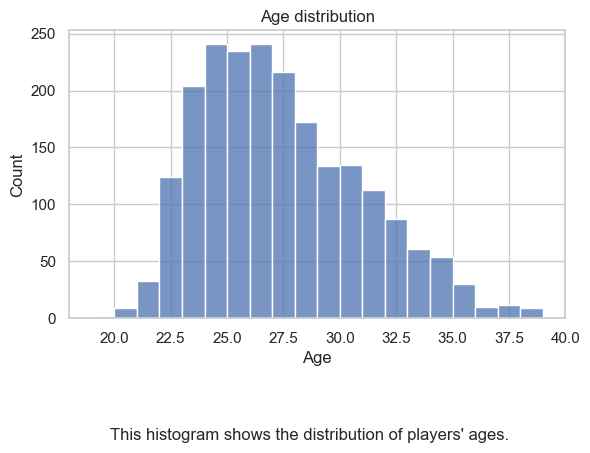

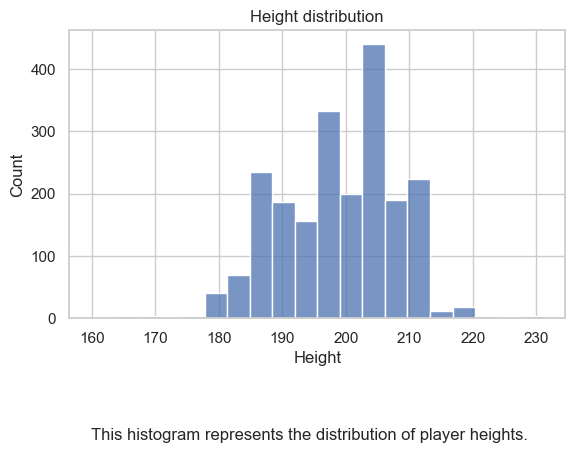

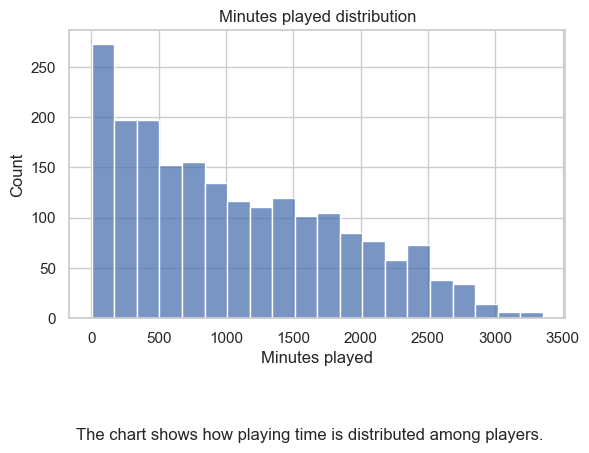

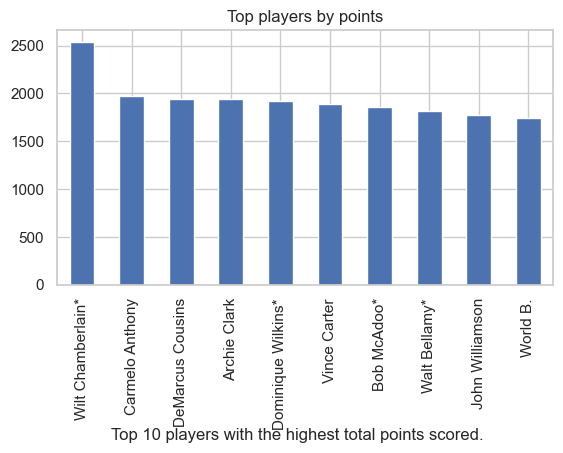

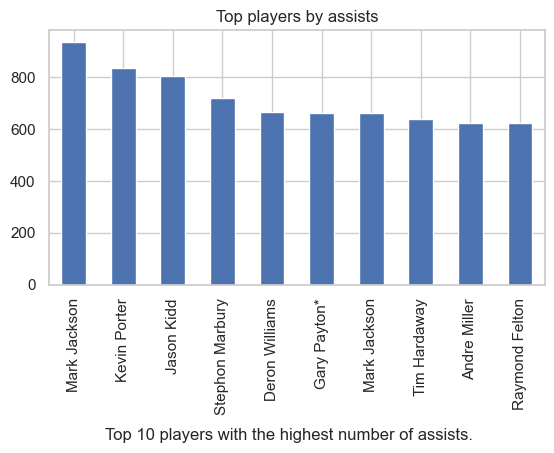

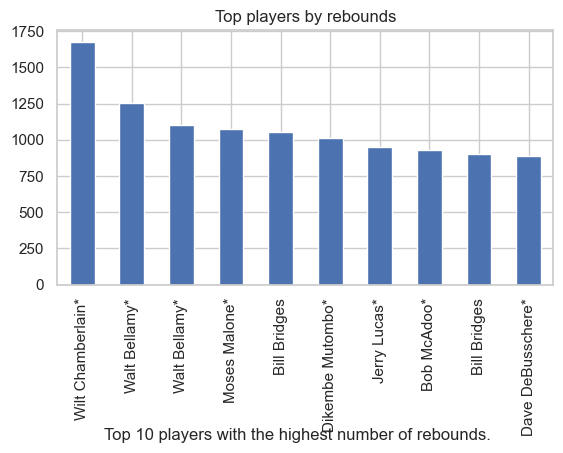

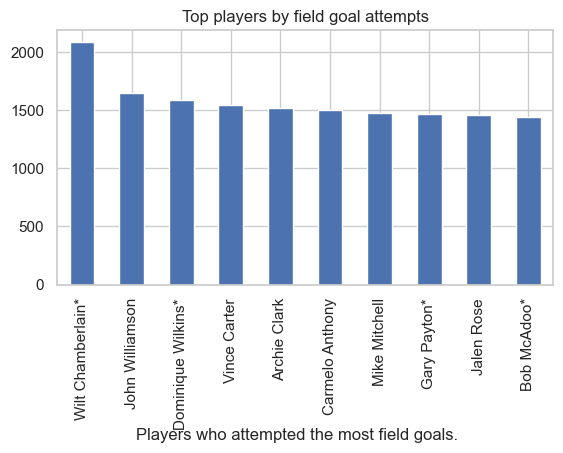

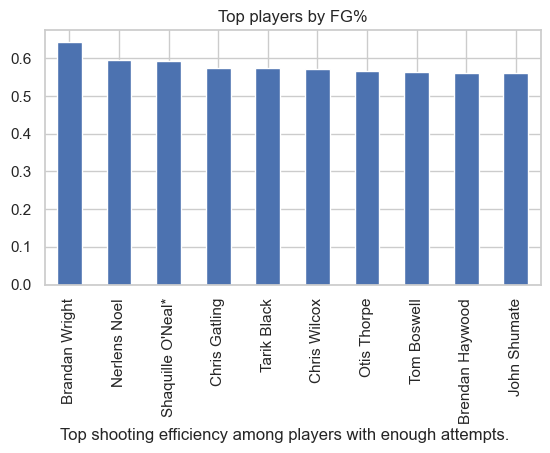

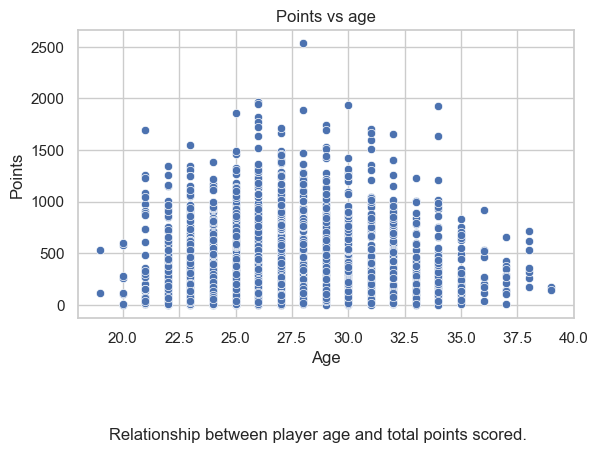

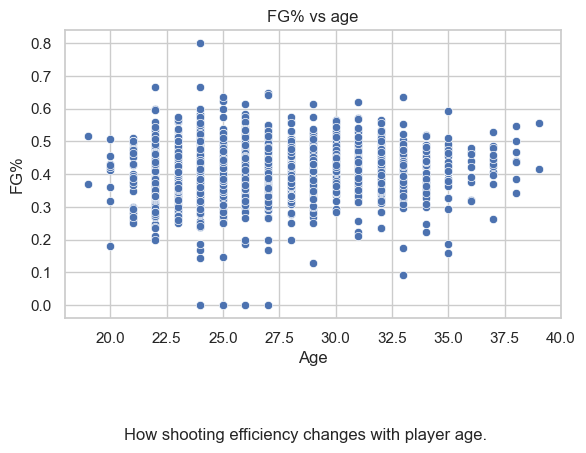

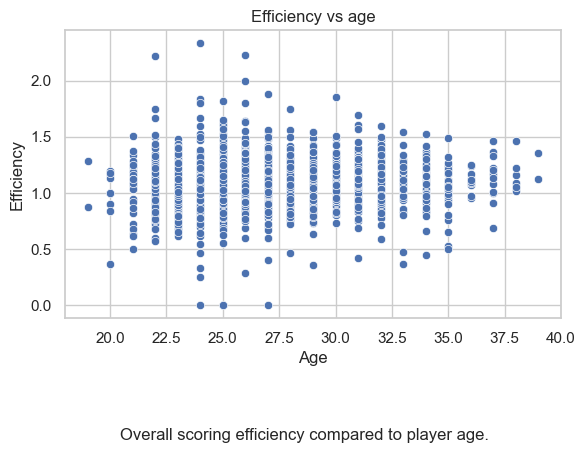

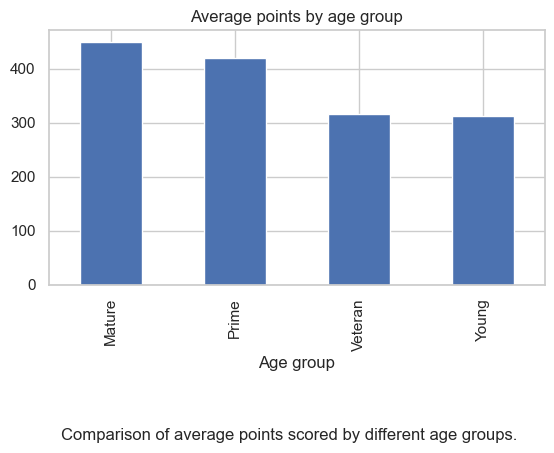

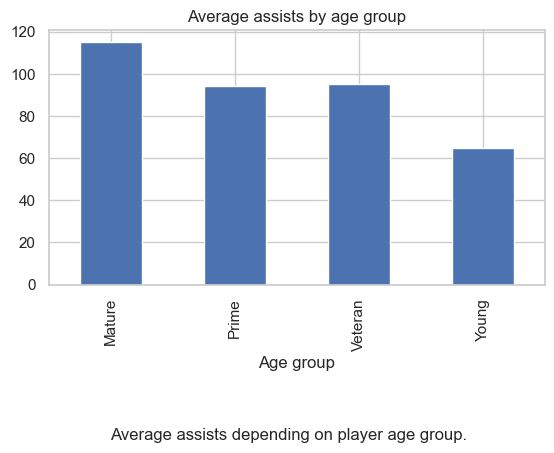

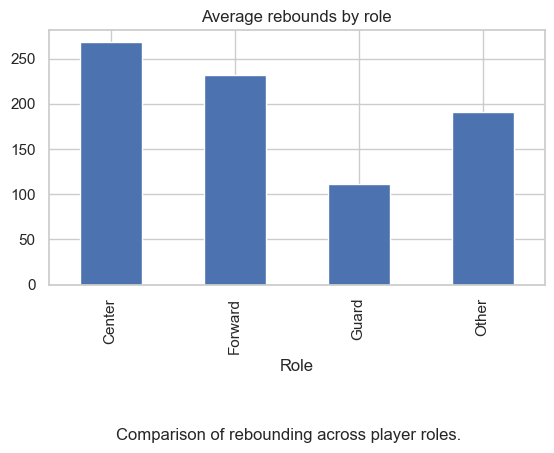

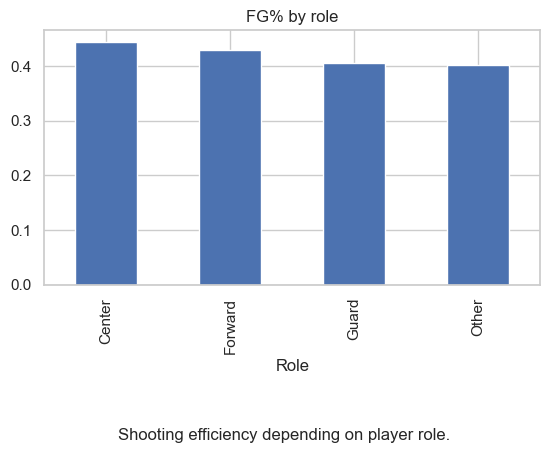

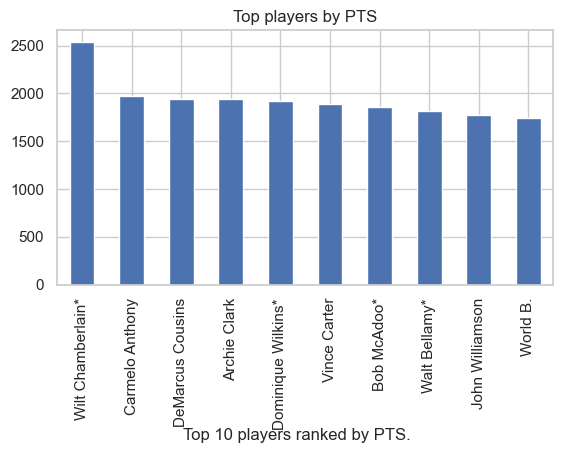

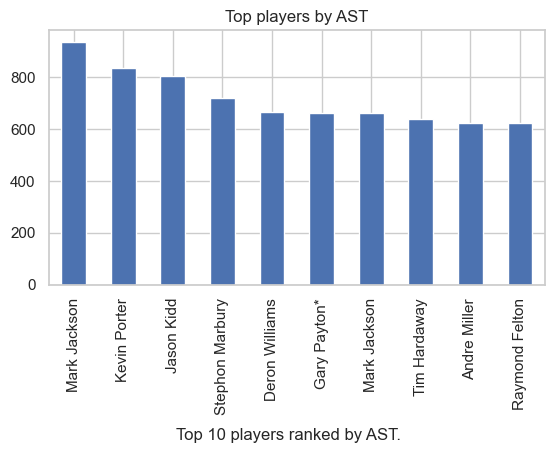

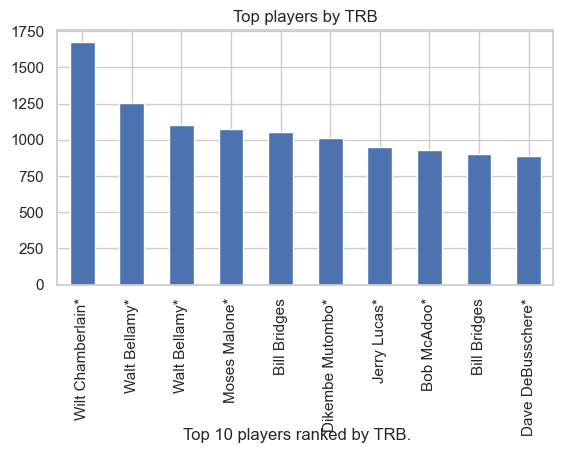

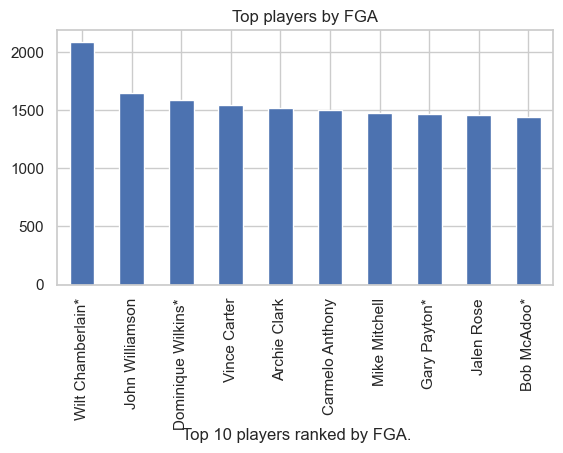

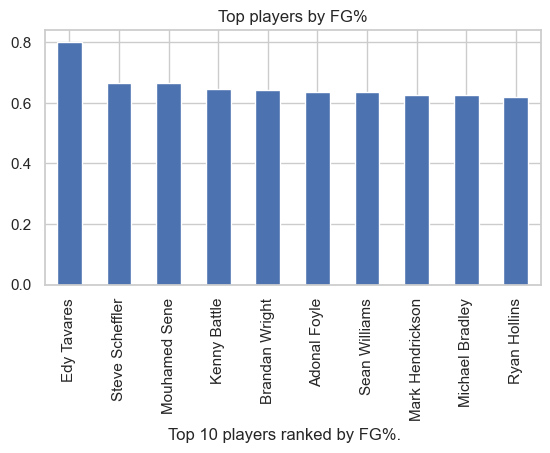

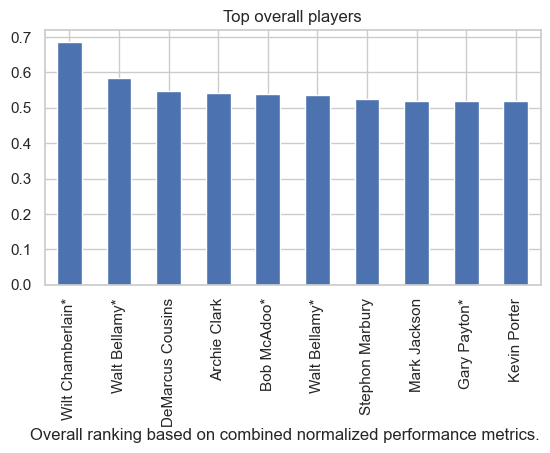

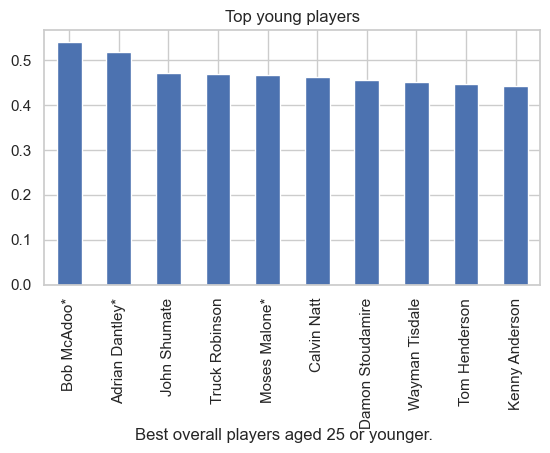

In [ ]:

stats["Efficiency"] = stats["PTS"] / stats["FGA"]
stats = stats[stats["FGA"] > 0]

# Age grouping

def age_group(age):
    if age <= 22:
        return "Young"
    elif age <= 29:
        return "Prime"
    elif age <= 34:
        return "Mature"
    else:
        return "Veteran"

stats["age_group"] = stats["Age"].apply(age_group)



# Role grouping

def role_group(pos):
    if pos in ["PG", "SG", "G"]:
        return "Guard"
    elif pos in ["SF", "PF", "F"]:
        return "Forward"
    elif pos == "C":
        return "Center"
    else:
        return "Other"

stats["role_group"] = stats["Pos"].apply(role_group)


def add_comment(fig, text, bottom=0.28):
    fig.subplots_adjust(bottom=bottom)
    fig.text(0.5, 0.02, text, ha="center", va="bottom")




# Distributions


# 1 Age
fig, ax = plt.subplots()
sns.histplot(stats["Age"], bins=20, ax=ax)
ax.set_title("Age distribution")
ax.set_xlabel("Age")
add_comment(fig, "This histogram shows the distribution of players' ages.")
plt.show()

# 2 Height
fig, ax = plt.subplots()
sns.histplot(stats["height"].dropna(), bins=20, ax=ax)
ax.set_title("Height distribution")
ax.set_xlabel("Height")
add_comment(fig, "This histogram represents the distribution of player heights.")
plt.show()

# 3 Minutes played
fig, ax = plt.subplots()
sns.histplot(stats["MP"], bins=20, ax=ax)
ax.set_title("Minutes played distribution")
ax.set_xlabel("Minutes played")
add_comment(fig, "The chart shows how playing time is distributed among players.")
plt.show()




# Top players by metrics


# 4 Points
fig, ax = plt.subplots()
stats.nlargest(10, "PTS").plot(x="Player", y="PTS", kind="bar", legend=False, ax=ax)
ax.set_title("Top players by points")
ax.set_xlabel("")
add_comment(fig, "Top 10 players with the highest total points scored.", bottom=0.35)
plt.show()

# 5 Assists
fig, ax = plt.subplots()
stats.nlargest(10, "AST").plot(x="Player", y="AST", kind="bar", legend=False, ax=ax)
ax.set_title("Top players by assists")
ax.set_xlabel("")
add_comment(fig, "Top 10 players with the highest number of assists.", bottom=0.35)
plt.show()

# 6 Rebounds
fig, ax = plt.subplots()
stats.nlargest(10, "TRB").plot(x="Player", y="TRB", kind="bar", legend=False, ax=ax)
ax.set_title("Top players by rebounds")
ax.set_xlabel("")
add_comment(fig, "Top 10 players with the highest number of rebounds.", bottom=0.35)
plt.show()

# 7 Field goal attempts
fig, ax = plt.subplots()
stats.nlargest(10, "FGA").plot(x="Player", y="FGA", kind="bar", legend=False, ax=ax)
ax.set_title("Top players by field goal attempts")
ax.set_xlabel("")
add_comment(fig, "Players who attempted the most field goals.", bottom=0.35)
plt.show()

# 8 Field goal percentage
fg_filtered = stats[stats["FGA"] > 200]
fig, ax = plt.subplots()
fg_filtered.nlargest(10, "FG%").plot(x="Player", y="FG%", kind="bar", legend=False, ax=ax)
ax.set_title("Top players by FG%")
ax.set_xlabel("")
add_comment(fig, "Top shooting efficiency among players with enough attempts.", bottom=0.35)
plt.show()




# Relationships with age


# 9 Points vs age
fig, ax = plt.subplots()
sns.scatterplot(data=stats, x="Age", y="PTS", ax=ax)
ax.set_title("Points vs age")
ax.set_xlabel("Age")
ax.set_ylabel("Points")
add_comment(fig, "Relationship between player age and total points scored.")
plt.show()

# 10 FG% vs age
fig, ax = plt.subplots()
sns.scatterplot(data=stats, x="Age", y="FG%", ax=ax)
ax.set_title("FG% vs age")
ax.set_xlabel("Age")
ax.set_ylabel("FG%")
add_comment(fig, "How shooting efficiency changes with player age.")
plt.show()

# 11 Efficiency vs age
fig, ax = plt.subplots()
sns.scatterplot(data=stats, x="Age", y="Efficiency", ax=ax)
ax.set_title("Efficiency vs age")
ax.set_xlabel("Age")
ax.set_ylabel("Efficiency")
add_comment(fig, "Overall scoring efficiency compared to player age.")
plt.show()






# Group comparisons


# 12 Points by age group
fig, ax = plt.subplots()
stats.groupby("age_group")["PTS"].mean().plot(kind="bar", ax=ax)
ax.set_title("Average points by age group")
ax.set_xlabel("Age group")
add_comment(fig, "Comparison of average points scored by different age groups.", bottom=0.35)
plt.show()

# 13 Assists by age group
fig, ax = plt.subplots()
stats.groupby("age_group")["AST"].mean().plot(kind="bar", ax=ax)
ax.set_title("Average assists by age group")
ax.set_xlabel("Age group")
add_comment(fig, "Average assists depending on player age group.", bottom=0.35)
plt.show()

# 14 Rebounds by role
fig, ax = plt.subplots()
stats.groupby("role_group")["TRB"].mean().plot(kind="bar", ax=ax)
ax.set_title("Average rebounds by role")
ax.set_xlabel("Role")
add_comment(fig, "Comparison of rebounding across player roles.", bottom=0.35)
plt.show()

# 15 FG% by role
fig, ax = plt.subplots()
stats.groupby("role_group")["FG%"].mean().plot(kind="bar", ax=ax)
ax.set_title("FG% by role")
ax.set_xlabel("Role")
add_comment(fig, "Shooting efficiency depending on player role.", bottom=0.35)
plt.show()




# Overall score


# 16 Top 10 by each metric
metrics = ["PTS", "AST", "TRB", "FGA", "FG%"]
for m in metrics:
    fig, ax = plt.subplots()
    stats.nlargest(10, m).plot(x="Player", y=m, kind="bar", legend=False, ax=ax)
    ax.set_title(f"Top players by {m}")
    ax.set_xlabel("")
    add_comment(fig, f"Top 10 players ranked by {m}.", bottom=0.35)
    plt.show()

# 17 Top overall players
score_metrics = ["PTS", "AST", "TRB", "FG%", "Efficiency"]
norm_stats = stats.copy()

for m in score_metrics:
    norm_stats[m] = (norm_stats[m] - norm_stats[m].min()) / (norm_stats[m].max() - norm_stats[m].min())

norm_stats["Overall_score"] = norm_stats[score_metrics].mean(axis=1)

fig, ax = plt.subplots()
norm_stats.nlargest(10, "Overall_score").plot(x="Player", y="Overall_score", kind="bar", legend=False, ax=ax)
ax.set_title("Top overall players")
ax.set_xlabel("")
add_comment(fig, "Overall ranking based on combined normalized performance metrics.", bottom=0.35)
plt.show()

# 18 Top young players
young_norm = norm_stats[norm_stats["Age"] <= 25]

fig, ax = plt.subplots()
young_norm.nlargest(10, "Overall_score").plot(x="Player", y="Overall_score", kind="bar", legend=False, ax=ax)
ax.set_title("Top young players")
ax.set_xlabel("")
add_comment(fig, "Best overall players aged 25 or younger.", bottom=0.35)
plt.show()
